<a href="https://colab.research.google.com/github/adamzsl/unsupervised-learning/blob/main/SRGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, IterableDataset
from torchvision import transforms, models
from torch.cuda.amp import autocast, GradScaler
from datasets import load_dataset
from PIL import Image
import random
import matplotlib.pyplot as plt


In [ ]:
class SplitIterableDataset(IterableDataset):
    def __init__(self, dataset, split="train"):
        self.dataset = dataset
        self.split = split

    def __iter__(self):
        for i, sample in enumerate(self.dataset):
            if self.split == "train" and i % 10 < 8:
                yield sample
            elif self.split == "val" and i % 10 == 8:
                yield sample


In [ ]:
class CharbonnierLoss(nn.Module):
    def __init__(self, eps=1e-3):
        super().__init__()
        self.eps = eps

    def forward(self, x, y):
        return torch.mean(torch.sqrt((x - y) ** 2 + self.eps ** 2))


In [ ]:
class WikiArtSRPatchDataset(IterableDataset):
    def __init__(self, hf_stream, hr_size=256, patch_size=128):
        self.dataset = hf_stream
        self.hr_size = hr_size
        self.patch_size = patch_size
        self.lr_size = patch_size // 2

        self.to_tensor = transforms.ToTensor()
        self.resize = transforms.Resize((hr_size, hr_size), Image.BICUBIC)

    def __iter__(self):
        for sample in self.dataset:
            img = sample["image"]
            if not isinstance(img, Image.Image):
                img = Image.fromarray(img)

            img = self.resize(img)

            x = random.randint(0, self.hr_size - self.patch_size)
            y = random.randint(0, self.hr_size - self.patch_size)

            hr = img.crop((x, y, x+self.patch_size, y+self.patch_size))
            lr = hr.resize((self.lr_size, self.lr_size), Image.BICUBIC)

            yield self.to_tensor(lr), self.to_tensor(hr)


In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, c=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(c, c, 3, 1, 1),
            nn.BatchNorm2d(c),
            nn.PReLU(),
            nn.Conv2d(c, c, 3, 1, 1),
            nn.BatchNorm2d(c),
        )

    def forward(self, x):
        return x + self.block(x)


class Generator(nn.Module):
    def __init__(self, n_blocks=8):
        super().__init__()

        self.entry = nn.Sequential(
            nn.Conv2d(3, 64, 9, 1, 4),
            nn.PReLU()
        )

        self.res = nn.Sequential(*[ResidualBlock() for _ in range(n_blocks)])

        self.mid = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1),
            nn.BatchNorm2d(64)
        )

        self.up = nn.Sequential(
            nn.Conv2d(64, 256, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.PReLU()
        )

        self.out = nn.Conv2d(64, 3, 9, 1, 4)

    def forward(self, x):
        x1 = self.entry(x)
        x2 = self.mid(self.res(x1))
        x = x1 + x2
        x = self.up(x)
        return self.out(x)


In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        def block(in_c, out_c, stride):
            return [
                nn.Conv2d(in_c, out_c, 3, stride, 1),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2)
            ]

        layers = []
        in_c = 3
        for out_c, s in [(64,1),(64,2),(128,1),(128,2),(256,1),(256,2)]:
            layers += block(in_c, out_c, s)
            in_c = out_c

        layers += [nn.Conv2d(256, 1, 3, 1, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [ ]:
class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.vgg = models.vgg19(weights="DEFAULT").features[:36].eval()
        for p in self.vgg.parameters():
            p.requires_grad = False

        self.register_buffer("mean", torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer("std",  torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))

    def forward(self, sr, hr):
        sr = (sr - self.mean) / self.std
        hr = (hr - self.mean) / self.std
        return nn.functional.l1_loss(self.vgg(sr), self.vgg(hr))


In [ ]:
class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.vgg = models.vgg19(weights="DEFAULT").features[:36].eval()
        for p in self.vgg.parameters():
            p.requires_grad = False

        self.register_buffer("mean", torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer("std",  torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))

    def forward(self, sr, hr):
        sr = (sr - self.mean) / self.std
        hr = (hr - self.mean) / self.std
        return nn.functional.l1_loss(self.vgg(sr), self.vgg(hr))


In [ ]:
def train_srgan(G, D, loader, epochs, lr_G, lr_D):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    G.to(device)
    D.to(device)

    opt_G = optim.Adam(G.parameters(), lr=lr_G)
    opt_D = optim.Adam(D.parameters(), lr=lr_D)

    pixel_loss = CharbonnierLoss()          # ← ZAMIANA L1
    adv_loss   = nn.BCEWithLogitsLoss()
    perceptual = VGGPerceptualLoss().to(device)

    scaler = GradScaler(enabled=(device == "cuda"))

    for epoch in range(epochs):
        for i, (lr_img, hr_img) in enumerate(loader):
            lr_img = lr_img.to(device)
            hr_img = hr_img.to(device)

            # ===== TRAIN DISCRIMINATOR =====
            with autocast():
                fake = G(lr_img).detach()
                d_loss = (
                    adv_loss(D(hr_img), torch.ones_like(D(hr_img))) +
                    adv_loss(D(fake), torch.zeros_like(D(fake)))
                )

            opt_D.zero_grad()
            scaler.scale(d_loss).backward()
            scaler.step(opt_D)

            # ===== TRAIN GENERATOR =====
            for p in D.parameters():
                p.requires_grad = False

            with autocast():
                fake = G(lr_img)

                loss_pixel = pixel_loss(fake, hr_img)
                loss_perc  = perceptual(fake, hr_img)
                loss_adv   = adv_loss(D(fake), torch.ones_like(D(fake)))

                # >>> KLUCZOWA ZMIANA WAG <<<
                g_loss = (
                    1.0   * loss_pixel +
                    0.05  * loss_perc +
                    0.005 * loss_adv
                )

            opt_G.zero_grad()
            scaler.scale(g_loss).backward()
            scaler.step(opt_G)
            scaler.update()

            for p in D.parameters():
                p.requires_grad = True

            if i == 100:
                break

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"D {d_loss.item():.4f} | "
            f"G {g_loss.item():.4f}"
        )


In [ ]:
hf = load_dataset("huggan/wikiart", split="train", streaming=True)
train_stream = SplitIterableDataset(hf, "train")

ds1 = WikiArtSRPatchDataset(train_stream, hr_size=256, patch_size=128)
loader1 = DataLoader(ds1, batch_size=8, num_workers=2)

G1 = Generator()
D1 = Discriminator()

train_srgan(
    G1,
    D1,
    loader1,
    epochs=8,     # możesz zostawić 8
    lr_G=1e-4,
    lr_D=5e-5     # ← MNIEJSZY LR D
)



Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

/tmp/ipython-input-496254400.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device == "cuda"))
/tmp/ipython-input-496254400.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-496254400.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/8 | D 1.2170 | G 0.1024
Epoch 2/8 | D 0.6788 | G 0.0862
Epoch 3/8 | D 0.4904 | G 0.0667
Epoch 4/8 | D 0.1404 | G 0.0620
Epoch 5/8 | D 0.7776 | G 0.0648
Epoch 6/8 | D 0.0999 | G 0.0696
Epoch 7/8 | D 0.0508 | G 0.0659
Epoch 8/8 | D 0.0411 | G 0.0610


In [ ]:
ds2 = WikiArtSRPatchDataset(train_stream, hr_size=512, patch_size=256)
loader2 = DataLoader(ds2, batch_size=4, num_workers=2)

G2 = Generator()
G2.load_state_dict(G1.state_dict())   # <<< KLUCZOWE
D2 = Discriminator()

train_srgan(
    G2,
    D2,
    loader2,
    epochs=5,     # OK
    lr_G=5e-5,    # mniejszy LR (fine-tuning)
    lr_D=2e-5     # jeszcze słabszy D
)



/tmp/ipython-input-496254400.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device == "cuda"))
/tmp/ipython-input-496254400.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-496254400.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/5 | D 1.3517 | G 0.0382
Epoch 2/5 | D 1.1727 | G 0.0385
Epoch 3/5 | D 0.9264 | G 0.0337
Epoch 4/5 | D 0.8403 | G 0.0347
Epoch 5/5 | D 0.6822 | G 0.0394


In [ ]:
from datasets import load_dataset
import random
from PIL import Image

# losowy obraz z WikiArt (pełny obraz, nie patch!)
wikiart_full = load_dataset(
    "huggan/wikiart",
    split="train",
    streaming=True
)

# wylosuj jeden obraz
sample = None
for i, s in enumerate(wikiart_full):
    if random.random() < 0.001:  # losowanie bez liczenia długości
        sample = s
        break

img = sample["image"]
if not isinstance(img, Image.Image):
    img = Image.fromarray(img)

print("Test image size:", img.size)


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 3788eb17-fc11-48ce-a97d-68f6e9554294)')' thrown while requesting GET https://huggingface.co/datasets/huggan/wikiart/resolve/d559852d2b232e0fcf195e775866964f0564f2b5/data/train-00000-of-00072.parquet
Retrying in 1s [Retry 1/5].


Test image size: (1382, 1581)


In [ ]:
import torch
import torch.nn.functional as F

def sr_full_image(
    model,
    lr_image,          # tensor [3, H, W] w [0,1]
    patch_size,
    overlap
):
    """
    Sliding-window super-resolution with correct padding and cropping.
    Fixes black borders and cut corners.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device).eval()

    scale = 2
    _, H, W = lr_image.shape
    stride = patch_size - overlap

    assert overlap < patch_size, "overlap must be smaller than patch_size"

    # === 1️⃣ PAD REFLECT (NAPRAWA BRZEGÓW)
    pad_h = (stride - H % stride) % stride
    pad_w = (stride - W % stride) % stride

    lr_padded = F.pad(
        lr_image.unsqueeze(0),
        (0, pad_w, 0, pad_h),
        mode="reflect"
    ).squeeze(0)

    _, Hp, Wp = lr_padded.shape

    # === 2️⃣ BUFOR WYJŚCIA
    out = torch.zeros(3, Hp * scale, Wp * scale, device=device)
    wgt = torch.zeros_like(out)

    lr_padded = lr_padded.to(device)

    # === 3️⃣ SLIDING WINDOW
    for y in range(0, Hp - patch_size + 1, stride):
        for x in range(0, Wp - patch_size + 1, stride):
            patch = lr_padded[:, y:y+patch_size, x:x+patch_size].unsqueeze(0)

            with torch.no_grad():
                sr = model(patch).squeeze(0)

            ys, xs = y * scale, x * scale
            out[:, ys:ys + patch_size * scale,
                   xs:xs + patch_size * scale] += sr
            wgt[:, ys:ys + patch_size * scale,
                   xs:xs + patch_size * scale] += 1

    # === 4️⃣ NORMALIZACJA + DOKŁADNE CIĘCIE DO ORYGINAŁU
    out = out / wgt.clamp(min=1e-6)
    out = out[:, :H * scale, :W * scale]

    return out.clamp(0, 1).cpu()


Final resolution: torch.Size([3, 1580, 1380])


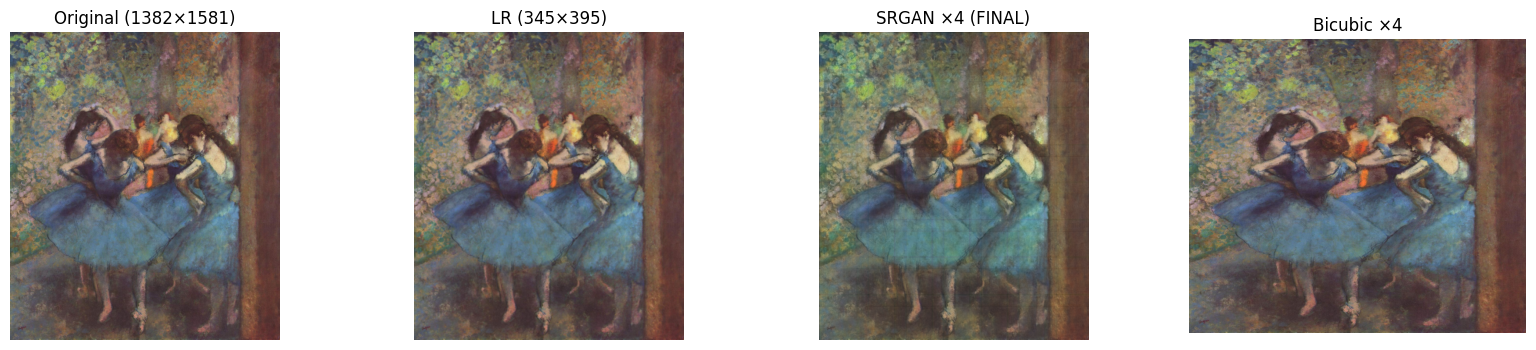

In [ ]:
from torchvision.transforms import Resize, ToTensor
import matplotlib.pyplot as plt


from torchvision.transforms import ToTensor, Resize

# --- ORYGINALNY OBRAZ ---
orig_tensor = ToTensor()(img)

# --- SYMULACJA NISKIEJ ROZDZIELCZOŚCI ---
# zmniejszamy, ALE ZACHOWUJEMY PROPORCJE
lr_img = Resize(
    (img.size[1] // 4, img.size[0] // 4),
    interpolation=Image.BICUBIC
)(img)

lr_tensor = ToTensor()(lr_img)

# --- ETAP 1: x2 ---
sr_x2 = sr_full_image(
    G1,
    lr_tensor,
    patch_size=64,
    overlap=16
)

# --- ETAP 2: x4 ---
sr_x4 = sr_full_image(
    G2,
    sr_x2,
    patch_size=128,
    overlap=32
)

print("Final resolution:", sr_x4.shape)

def show(img, title):
    plt.imshow(img.permute(1,2,0))
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(20,4))

plt.subplot(1,4,1)
show(orig_tensor, f"Original ({img.size[0]}×{img.size[1]})")

plt.subplot(1,4,2)
show(lr_tensor, f"LR ({lr_tensor.shape[2]}×{lr_tensor.shape[1]})")

plt.subplot(1,4,3)
show(sr_x4, "SRGAN ×4 (FINAL)")

plt.subplot(1,4,4)
show(ToTensor()(img.resize(sr_x4.shape[1:])), "Bicubic ×4")

plt.show()

